![MuJoCo banner](https://raw.githubusercontent.com/google-deepmind/mujoco/main/banner.png)







### Copyright notice

> <p><small><small>Copyright 2025 DeepMind Technologies Limited.</small></p>
> <p><small><small>Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at <a href="http://www.apache.org/licenses/LICENSE-2.0">http://www.apache.org/licenses/LICENSE-2.0</a>.</small></small></p>
> <p><small><small>Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.</small></small></p>

# Manipulation in The Playground! <a href="https://colab.research.google.com/github/google-deepmind/mujoco_playground/blob/main/learning/notebooks/manipulation.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" width="140" align="center"/></a>

In this notebook, we'll walk through a couple manipulation environments available in MuJoCo Playground.

**A Colab runtime with GPU acceleration is required.** If you're using a CPU-only runtime, you can switch using the menu "Runtime > Change runtime type".


In [1]:
#@title Install pre-requisites
#!pip install mujoco mujoco_mjx brax --quiet

### Check of CUDA and Apple Compatibility

In [2]:
#@title Install pre-requisites (CPU-only for Apple Silicon)
import os
import platform
import subprocess
import sys

def is_nvidia_available():
    """Check if nvidia-smi is callable (Linux/Colab with GPU)."""
    try:
        result = subprocess.run(
            ["nvidia-smi"], stdout=subprocess.PIPE, stderr=subprocess.PIPE
        )
        return result.returncode == 0
    except FileNotFoundError:
        return False

system = platform.system()
machine = platform.machine()

if system == "Darwin":  # macOS (Apple Silicon / Intel Mac)
    print("Detected macOS:", machine)
    # Force MuJoCo to use glfw rendering
    os.environ["MUJOCO_GL"] = "glfw"
    print("Using MUJOCO_GL=glfw for macOS")
    # Force JAX to CPU (avoid Metal/MPS backend issues)
    os.environ["JAX_PLATFORM_NAME"] = "cpu"
    print("Forcing JAX to run on CPU backend")

elif is_nvidia_available():  # Linux + NVIDIA GPU
    print("Detected NVIDIA GPU")
    os.environ["MUJOCO_GL"] = "egl"
    print("Using MUJOCO_GL=egl for GPU rendering")

    # Add missing EGL ICD config if necessary (Colab hack)
    NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
    if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
        with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
            f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")
else:  # Fallback (no GPU)
    print("No NVIDIA GPU detected, running in CPU/OSMesa mode")
    os.environ["MUJOCO_GL"] = "osmesa"
    os.environ["JAX_PLATFORM_NAME"] = "cpu"

# --- Test Mujoco ---
try:
    import mujoco
    mujoco.MjModel.from_xml_string('<mujoco/>')
    print("Mujoco installation and rendering backend OK")
except Exception as e:
    print("❌ Mujoco test failed:", e)

Detected macOS: arm64
Using MUJOCO_GL=glfw for macOS
Forcing JAX to run on CPU backend
Mujoco installation and rendering backend OK


In [3]:
# # @title Check if MuJoCo installation was successful

# import distutils.util
# import os
# import subprocess

# if subprocess.run('nvidia-smi').returncode:
#   raise RuntimeError(
#       'Cannot communicate with GPU. '
#       'Make sure you are using a GPU Colab runtime. '
#       'Go to the Runtime menu and select Choose runtime type.'
#   )

# # Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# # This is usually installed as part of an Nvidia driver package, but the Colab
# # kernel doesn't install its driver via APT, and as a result the ICD is missing.
# # (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
# NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
# if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
#   with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
#     f.write("""{
#     "file_format_version" : "1.0.0",
#     "ICD" : {
#         "library_path" : "libEGL_nvidia.so.0"
#     }
# }
# """)

# # Configure MuJoCo to use the EGL rendering backend (requires GPU)
# print('Setting environment variable to use GPU rendering:')
# %env MUJOCO_GL=egl

# try:
#   print('Checking that the installation succeeded:')
#   import mujoco

#   mujoco.MjModel.from_xml_string('<mujoco/>')
# except Exception as e:
#   raise e from RuntimeError(
#       'Something went wrong during installation. Check the shell output above '
#       'for more information.\n'
#       'If using a hosted Colab runtime, make sure you enable GPU acceleration '
#       'by going to the Runtime menu and selecting "Choose runtime type".'
#   )

# print('Installation successful.')

# # Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
# xla_flags = os.environ.get('XLA_FLAGS', '')
# xla_flags += ' --xla_gpu_triton_gemm_any=True'
# os.environ['XLA_FLAGS'] = xla_flags

In [4]:
# # @title Import packages for plotting and creating graphics
# import json
# import itertools
# import time
# from typing import Callable, List, NamedTuple, Optional, Union
# import numpy as np

# # Graphics and plotting.
# print("Installing mediapy:")
# !command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
# !pip install -q mediapy
# import mediapy as media
# import matplotlib.pyplot as plt

# # More legible printing from numpy.
# np.set_printoptions(precision=3, suppress=True, linewidth=100)

### Check Critical Package Version
✅ JAX: 0.6.2
✅ MuJoCo: 3.3.6
✅ Brax: 0.13.0
✅ Flax: 0.10.7

In [5]:
# Version check
import jax, mujoco, brax, flax
print("JAX:", jax.__version__)
print("MuJoCo:", mujoco.__version__)
print("Brax:", brax.__version__)
print("Flax:", flax.__version__)


Failed to import warp: No module named 'warp'
Failed to import mujoco.mjx.third_party.mujoco_warp as mujoco_warp: No module named 'warp'
JAX: 0.6.2
MuJoCo: 3.3.6
Brax: 0.13.0
Flax: 0.10.7


In [6]:
# @title Import packages for plotting and creating graphics
import json
import itertools
import time
from typing import Callable, List, NamedTuple, Optional, Union
import numpy as np

# Graphics and plotting.
print("Installing mediapy & ffmpeg if needed...")


system = platform.system()
if system == "Linux":
    # Works in Colab/Ubuntu
    !command -v ffmpeg >/dev/null || (apt-get update -qq && apt-get install -y ffmpeg)
elif system == "Darwin":
    # On macOS, assume ffmpeg is installed via Homebrew, or ask user
    !command -v ffmpeg >/dev/null || echo " Please install ffmpeg with: brew install ffmpeg"

# !brew install ffmpeg
# !pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

Installing mediapy & ffmpeg if needed...


In [7]:
# @title Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools
import os
from typing import Any, Dict, Sequence, Tuple, Union
from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from brax.training.agents.sac import networks as sac_networks
from brax.training.agents.sac import train as sac
from etils import epath
from flax import struct
from flax.training import orbax_utils
from IPython.display import HTML, clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
import mujoco.viewer
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp
import os
import pickle
import numpy as np

## Number of CPU Cores used

to be able to utilze a multiple of 8 in the num_env, batch and minibatch size. we need to utilize only 8 and not 14 cores

In [8]:
import jax
import os

# must be done BEFORE "import jax"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=8"


devices = jax.devices()
device_count = len(devices)
print(devices)
print("JAX device count:", device_count)


[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]
JAX device count: 8


# Manipulation

MuJoCo Playground contains several manipulation environments (all listed below after running the command).

In [9]:
# #@title Install MuJoCo Playground
#!pip install playground


In [10]:
print("MuJoCo:", mujoco.__version__)
print("MJX ready:", hasattr(mjx.Data, "_impl"))

# MuJoCo: 3.1.4
# MJX ready: True

MuJoCo: 3.3.6
MJX ready: False


In [11]:
#@title Import The Playground

from mujoco_playground import wrapper
from mujoco_playground import registry

# Manipulation

MuJoCo Playground contains several manipulation environments (all listed below after running the command).

In [12]:
registry.manipulation.ALL_ENVS

('AlohaHandOver',
 'AlohaSinglePegInsertion',
 'PandaPickCube',
 'UR10PickCube',
 'PandaPickCubeOrientation',
 'PandaPickCubeCartesian',
 'PandaOpenCabinet',
 'PandaRobotiqPushCube',
 'LeapCubeReorient',
 'LeapCubeRotateZAxis')

# Franka Emika Panda

Let's start off with the simplest environment, simply picking up a cube with the Franka Emika Panda.

In [13]:
env_name = 'UR10PickCube'
env = registry.load(env_name)
env_cfg = registry.get_default_config(env_name)

✓ Using keyframe: 'low_home'
  Initial qpos size: 15
  Robot joints: [ 0.   -1.7   2.25 -2.15 -1.5  -1.5   0.    0.  ]
Available sensors:
  - left_finger_pad_floor_found
  - right_finger_pad_floor_found
  - hand_capsule_floor_found
  - box_hand_found
  - left_finger_box_contact
  - right_finger_box_contact
  - tcp_position
  - box_position


In [14]:
model = mujoco.MjModel.from_xml_path('../../mujoco_playground/_src/manipulation/my_ur10/xmls/mjx_single_cube_position.xml')
data = mujoco.MjData(model)



## Train Policy

Let's train the pick cube policy and visualize rollouts. The policy takes roughly 3 minutes to train on an RTX 4090.

In [15]:
from mujoco_playground.config import manipulation_params
env_name = 'UR10PickCube'
ppo_params = manipulation_params.brax_ppo_config(env_name)
ppo_params

action_repeat: 1
batch_size: 512
discounting: 0.97
entropy_cost: 0.02
episode_length: 150
learning_rate: 0.001
network_factory:
  policy_hidden_layer_sizes: !!python/tuple
  - 32
  - 32
  - 32
  - 32
  policy_obs_key: state
  value_hidden_layer_sizes: !!python/tuple
  - 256
  - 256
  - 256
  - 256
  - 256
  value_obs_key: state
normalize_observations: true
num_envs: 2048
num_evals: 4
num_minibatches: 32
num_resets_per_eval: 10
num_timesteps: 20000000
num_updates_per_batch: 8
reward_scaling: 1.0
unroll_length: 10

In [16]:
from copy import deepcopy

# Make a copy so you don't overwrite the original defaults
fast_ppo_params = deepcopy(ppo_params)

# --- Speedup adjustments ---
fast_ppo_params["num_timesteps"] = 10_000_000 
# fast_ppo_params["learning_rate"] = 0.002        
# fast_ppo_params["episode_length"] = 200        
# fast_ppo_params["unroll_length"] = 10         

# (Optional) reduce parallel envs to lower compute requirements
# fast_ppo_params["num_envs"] = 2048              # from 8192 or 4096 or 2048
# print("Adjusted num_envs:", fast_ppo_params["num_envs"])

# (Optional) tweak batch sizes accordingly !! Needs to be 
# fast_ppo_params["batch_size"] = 256             
# fast_ppo_params["num_minibatches"] = 16         

ppo_params = fast_ppo_params
ppo_params

action_repeat: 1
batch_size: 512
discounting: 0.97
entropy_cost: 0.02
episode_length: 150
learning_rate: 0.001
network_factory:
  policy_hidden_layer_sizes: !!python/tuple
  - 32
  - 32
  - 32
  - 32
  policy_obs_key: state
  value_hidden_layer_sizes: !!python/tuple
  - 256
  - 256
  - 256
  - 256
  - 256
  value_obs_key: state
normalize_observations: true
num_envs: 2048
num_evals: 4
num_minibatches: 32
num_resets_per_eval: 10
num_timesteps: 10000000
num_updates_per_batch: 8
reward_scaling: 1.0
unroll_length: 10

### PPO

In [17]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]


def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())

ppo_training_params = dict(ppo_params)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
  del ppo_training_params["network_factory"]
  network_factory = functools.partial(
      ppo_networks.make_ppo_networks,
      **ppo_params.network_factory
  )

train_fn = functools.partial(
    ppo.train, **dict(ppo_training_params),
    network_factory=network_factory,
    progress_fn=progress,
    seed=1
)

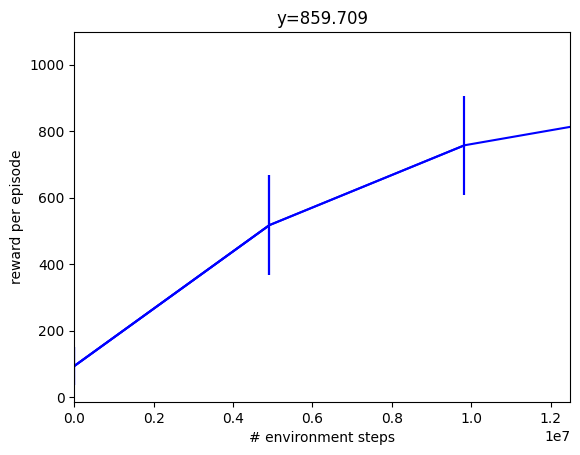

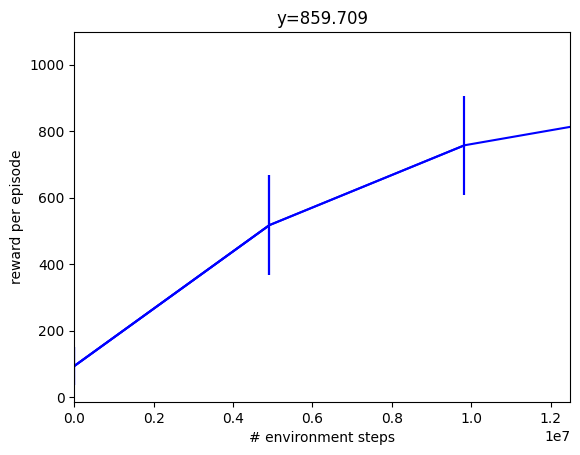

In [18]:
make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
if y_data:
    import numpy as np
    best_idx = int(np.argmax(y_data))

### Metrics of Training
Rewards over 1000 yield decent results
With default training time reward is 1347 after 20'152'320

In [19]:
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")
print(f"Highest Reward: {y_data[best_idx]:.3f} ± {y_dataerr[best_idx]:.3f} at step {x_data[best_idx]}")

time to jit: 0:06:29.662979
time to train: 0:14:47.417260
Highest Reward: 859.709 ± 187.692 at step 14745600


## Visualize Rollouts

In [20]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

In [23]:
import jax
import jax.numpy as jp
import numpy as np
import mujoco
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# --------------------------------------
# Reset env
# --------------------------------------
rng = jax.random.PRNGKey(0)
state = jit_reset(rng)

# --------------------------------------
# Build a MuJoCo renderer from the same XML
# --------------------------------------
xml_path = "../../mujoco_playground/_src/manipulation/my_ur10/xmls/mjx_single_cube_position.xml"
model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model, height=480, width=640)

cam = mujoco.MjvCamera()
cam.type = mujoco.mjtCamera.mjCAMERA_FREE
cam.lookat[:] = [0.0, 0.0, 0.35]
cam.distance = 2.0
cam.azimuth = 130
cam.elevation = -20

# --------------------------------------
# Rollout settings
# --------------------------------------
num_steps = 200
render_every = 2
sleep_s = 0.03

frames = []

for t in range(num_steps):
    obs = state.obs
    action, _ = jit_inference_fn(obs, rng)
    state = jit_step(state, action)

    # Copy MJX state into standard MuJoCo data for rendering
    data.qpos[:] = np.array(state.data.qpos)
    data.qvel[:] = np.array(state.data.qvel)
    data.ctrl[:] = np.array(state.data.ctrl)

    # mocap target, if used by your env
    if hasattr(state.data, "mocap_pos"):
        data.mocap_pos[:] = np.array(state.data.mocap_pos)
    if hasattr(state.data, "mocap_quat"):
        data.mocap_quat[:] = np.array(state.data.mocap_quat)

    mujoco.mj_forward(model, data)

    if t % render_every == 0:
        renderer.update_scene(data, camera=cam)
        img = renderer.render()
        frames.append(img)

    if float(state.done) > 0.0:
        print(f"Episode ended at step {t}")
        break

print(f"Collected {len(frames)} frames.")

Episode ended at step 134
Collected 68 frames.


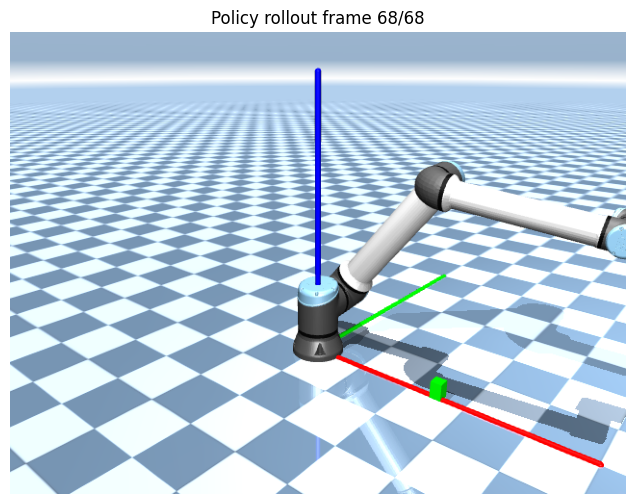

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

for i, img in enumerate(frames):
    clear_output(wait=True)
    ax.clear()
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"Policy rollout frame {i+1}/{len(frames)}")
    display(fig)
    time.sleep(sleep_s)

plt.close(fig)

In [32]:
import os
import json
import pickle
from pathlib import Path
import jax
import jax.numpy as jp

save_dir = Path("../../evaluation/downloaded_policies/reach_policy")
save_dir.mkdir(parents=True, exist_ok=True)

# --------------------------
# 1. Save params
# --------------------------
with open(save_dir / "params.pkl", "wb") as f:
    pickle.dump(params, f)

# --------------------------
# 2. Save metrics
# --------------------------
with open(save_dir / "metrics.pkl", "wb") as f:
    pickle.dump(metrics, f)

# --------------------------
# 3. Save metadata / config
# --------------------------
metadata = {
    "policy_name": "reach_policy",
    "env_name": type(env).__name__,
    "saved_from_branch": "current_branch_unknown",
    "notes": "UR10 reach policy trained locally with Brax PPO.",
}

with open(save_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved policy artifacts to: {save_dir.resolve()}")
print(list(save_dir.iterdir()))

Saved policy artifacts to: /Users/matthiasweiss/Desktop/ZHAW/MSE/3_VT1_Model Based RL/My_Mujoco/my_mujoco_playground/evaluation/downloaded_policies/reach_policy
[PosixPath('../../evaluation/downloaded_policies/reach_policy/params.pkl'), PosixPath('../../evaluation/downloaded_policies/reach_policy/metadata.json'), PosixPath('../../evaluation/downloaded_policies/reach_policy/metrics.pkl')]


In [33]:
readme = """reach_policy

Saved local UR10 reach PPO policy.
This policy is intended to output the next action step for later inference.
Requires compatible env obs/action dimensions when loading.
"""

with open(save_dir / "README.txt", "w") as f:
    f.write(readme)